# Simulation-Based Inference

In the [Getting Started](getting_started.ipynb) tutorial we built Bayesian models where the likelihood — the probability of data given parameters — has a known mathematical form. This let MCMC methods like NUTS sample the posterior by evaluating the log-density at each step.

But many scientific models are *simulators*: programs that generate synthetic data from parameters without ever writing down a likelihood function. Examples include stochastic differential equations in finance, agent-based models in epidemiology, and particle physics simulators. **Simulation-based inference (SBI)** methods handle these models by learning about the posterior purely from simulated data (Cranmer, Brehmer & Louppe, 2020).

ProbPipe integrates SBI through the same `condition_on` interface used for MCMC. This tutorial introduces:

- **`SimpleGenerativeModel`** — a model type for simulators (no likelihood required)
- **Neural Posterior Estimation (NPE)** — an *amortized* method: train a neural network once, then get fast posteriors for any observation
- **Sequential Monte Carlo ABC (SMCABC)** — a *non-amortized* method: run from scratch for each observation

We use the **Gaussian location model** — a standard SBI benchmark (Lueckmann et al., 2021) — because its likelihood is tractable, letting us compare SBI results against the exact posterior.

> **Prerequisites:** [Getting Started tutorial](getting_started.ipynb). SBI features require `pip install probpipe[sbi]`.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore', message=r'Explicitly requested dtype.*float64.*')
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import jax, jax.numpy as jnp, numpy as np, matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.default'] = 'regular'

from probpipe import (
    Normal, SimpleModel, SimpleGenerativeModel,
    condition_on, train_sbi, sample, mean, variance,
)
from probpipe.inference import ApproximateDistribution

## 1. The Gaussian location model

Our running example is the Gaussian location model, one of the standard benchmarks in the SBI literature (Lueckmann et al., 2021; Papamakarios & Murray, 2016). The model is:

$$\theta \sim \mathcal{N}(0, 1) \qquad y_i \mid \theta \sim \mathcal{N}(\theta,\, \sigma^2), \quad i = 1, \ldots, n$$

with known noise scale $\sigma$. Because the likelihood is conjugate to the prior, the exact posterior is available in closed form:

$$\theta \mid y_{1:n} \sim \mathcal{N}\!\left(\frac{n\bar{y}/\sigma^2}{1 + n/\sigma^2},\; \frac{1}{1 + n/\sigma^2}\right)$$

This lets us verify that SBI methods recover the correct posterior.

In [2]:
# Model parameters
theta_true = 2.0
noise_scale = 1.0
n_obs = 5

# Generate observed data
key = jax.random.PRNGKey(42)
y_obs = theta_true + noise_scale * jax.random.normal(key, shape=(n_obs,))
print(f'True θ = {theta_true}')
print(f'Observed data: {y_obs}')
print(f'Sample mean: {float(jnp.mean(y_obs)):.3f}')

True θ = 2.0
Observed data: [1.9716954 2.4671319 2.295703  2.1535459 1.8759671]
Sample mean: 2.153


In [3]:
# Exact conjugate posterior
prior_mean, prior_var = 0.0, 1.0
posterior_precision = 1 / prior_var + n_obs / noise_scale**2
exact_var = 1 / posterior_precision
exact_mean = float(exact_var * (prior_mean / prior_var + jnp.sum(y_obs) / noise_scale**2))
exact_std = float(jnp.sqrt(exact_var))

print(f'Exact posterior: N({exact_mean:.3f}, {exact_std:.3f}\u00b2)')

Exact posterior: N(1.794, 0.408²)


## 2. Defining the observation model

We define a single class that implements *both* ProbPipe protocols:

- **`Likelihood`** — provides `log_likelihood(params, data)` for MCMC
- **`GenerativeLikelihood`** — provides `generate_data(params, n_samples, *, key)` for SBI

This illustrates a key design point: the *same* scientific model can be used with different inference strategies depending on which protocol ProbPipe dispatches through.

In [4]:
class GaussianObservationModel:
    """Gaussian observation model: y_i | theta ~ N(theta, sigma^2).

    Implements both Likelihood and GenerativeLikelihood protocols.
    """

    def __init__(self, noise_scale, n_obs):
        self.noise_scale = noise_scale
        self.n_obs = n_obs

    def log_likelihood(self, params, data):
        return jnp.sum(jax.scipy.stats.norm.logpdf(
            data, loc=params, scale=self.noise_scale,
        ))

    def generate_data(self, params, n_samples, *, key=None):
        if key is None:
            key = jax.random.PRNGKey(0)
        noise = jax.random.normal(key, shape=(n_samples, self.n_obs))
        return jnp.atleast_1d(params) + self.noise_scale * noise


observation_model = GaussianObservationModel(noise_scale, n_obs)

## 3. MCMC baseline

First, we fit the model using MCMC — exactly as in the Getting Started tutorial. A `SimpleModel` pairs a prior (with log-density) and a `Likelihood` (with `log_likelihood`). The inference registry auto-selects NUTS.

In [5]:
prior = Normal(loc=0.0, scale=1.0)
model_mcmc = SimpleModel(prior, observation_model, name='gaussian_mcmc')

posterior_mcmc = condition_on(
    model_mcmc, y_obs,
    num_results=2000, num_warmup=1000, random_seed=0,
)
print(f'Algorithm:      {posterior_mcmc.algorithm}')
print(f'Posterior mean: {mean(posterior_mcmc).item():.3f}  (exact: {exact_mean:.3f})')

Algorithm:      tfp_nuts
Posterior mean: 1.773  (exact: 1.794)


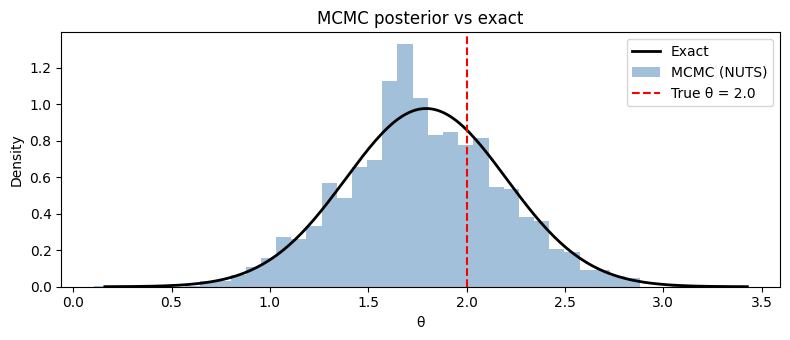

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))

x_grid = np.linspace(exact_mean - 4 * exact_std, exact_mean + 4 * exact_std, 200)
exact_pdf = jax.scipy.stats.norm.pdf(x_grid, exact_mean, exact_std)
ax.plot(x_grid, exact_pdf, 'k-', lw=2, label='Exact')

draws_mcmc = np.array(posterior_mcmc.draws()).ravel()
ax.hist(draws_mcmc, bins=40, density=True, alpha=0.5, color='steelblue', label='MCMC (NUTS)')
ax.axvline(theta_true, color='red', ls='--', lw=1.5, label=f'True θ = {theta_true}')

ax.set(xlabel='θ', ylabel='Density', title='MCMC posterior vs exact')
ax.legend(); plt.tight_layout(); plt.show()

## 4. From likelihood to simulator

Now suppose we *cannot* evaluate the likelihood — we can only *simulate* data. In ProbPipe, this means switching from `SimpleModel` to `SimpleGenerativeModel`.

| | `SimpleModel` | `SimpleGenerativeModel` |
|---|---|---|
| **Prior** | must support `log_prob` | must support `sample` |
| **Likelihood** | `log_likelihood(params, data)` | `generate_data(params, n, *, key)` |
| **Inference** | MCMC (NUTS, HMC, RWMH) | SBI (NPE, NLE, SMCABC) |

The key ProbPipe principle: **the model type determines which inference methods are feasible, and the registry auto-selects the best one.** You use `condition_on` either way.

In [7]:
model_sbi = SimpleGenerativeModel(prior, observation_model, name='gaussian_sbi')
print(model_sbi)
print(f'Components: {model_sbi.component_names}')
print(f'Parameters: {model_sbi.parameter_names}')

SimpleGenerativeModel(prior=Normal, likelihood=GaussianObservationModel)
Components: ('parameters', 'data')
Parameters: ('parameters',)


## 5. Amortized inference with Neural Posterior Estimation

**Neural Posterior Estimation (NPE)** (Papamakarios & Murray, 2016; Lueckmann et al., 2017) trains a neural density estimator — here, a masked autoregressive flow — to approximate the posterior $p(\theta \mid y)$ as a function of $y$. Training uses simulated $(\theta, y)$ pairs drawn from the joint model.

The key advantage is **amortization**: once trained, the network produces posterior samples for *any* observation instantly, without re-running inference. This is valuable when you need posteriors for many different observations under the same model.

In ProbPipe, `train_sbi` is a workflow function that returns a `TrainedSBIModel`. This object implements the `SupportsConditioning` protocol, so `condition_on` dispatches directly to the trained network — no registry lookup needed.

In [8]:
trained_model = train_sbi(
    prior, observation_model,
    method="npe",
    n_simulations=10_000,
    n_iter=1_000,
    batch_size=128,
    n_samples=4000,
    random_seed=42,
)
print(trained_model)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 1/1000 [00:01<24:28,  1.47s/it]

  0%|          | 2/1000 [00:02<18:16,  1.10s/it]

  0%|          | 3/1000 [00:03<15:52,  1.05it/s]

  0%|          | 4/1000 [00:04<15:51,  1.05it/s]

...

  2%|▏         | 22/1000 [00:18<13:27,  1.21it/s]

  2%|▏         | 23/1000 [00:19<13:17,  1.22it/s]

  2%|▏         | 24/1000 [00:20<13:08,  1.24it/s]

  2%|▏         | 24/1000 [00:21<14:23,  1.13it/s]

TrainedSBIModel(algorithm='sbijax_npe', n_samples=4000)


In [9]:
posterior_npe = condition_on(trained_model, y_obs)

print(f'Algorithm:      {posterior_npe.algorithm}')
print(f'Posterior mean: {mean(posterior_npe).item():.3f}  (exact: {exact_mean:.3f})')
print(f'Posterior std:  {jnp.sqrt(variance(posterior_npe)).item():.3f}  (exact: {exact_std:.3f})')
print(f'Type:           {type(posterior_npe).__name__}')

Algorithm:      sbijax_npe
Posterior mean: 1.780  (exact: 1.794)
Posterior std:  0.444  (exact: 0.408)
Type:           ApproximateDistribution


## 6. Non-amortized inference with SMCABC

**Sequential Monte Carlo ABC** (Sisson, Fan & Beaumont, 2007; Toni et al., 2009) is a likelihood-free method that iteratively refines a particle approximation to the posterior. Unlike NPE, it runs from scratch for each observation — there is no training step.

In ProbPipe, SMCABC is registered as an inference method for `SimpleGenerativeModel`. When you call `condition_on` on a `SimpleGenerativeModel`, the registry auto-selects SMCABC (since MCMC methods are not feasible without a likelihood). You can also request it explicitly with `method="sbijax_smcabc"`.

In [10]:
posterior_abc = condition_on(
    model_sbi, y_obs,
    n_rounds=5,
    n_particles=2000,
    random_seed=42,
)

print(f'Algorithm:      {posterior_abc.algorithm}')
print(f'Posterior mean: {mean(posterior_abc).item():.3f}  (exact: {exact_mean:.3f})')
print(f'Posterior std:  {jnp.sqrt(variance(posterior_abc)).item():.3f}  (exact: {exact_std:.3f})')

  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:12<00:50, 12.67s/it]

 40%|████      | 2/5 [00:19<00:28,  9.38s/it]

 60%|██████    | 3/5 [00:29<00:19,  9.64s/it]

 80%|████████  | 4/5 [00:39<00:09,  9.88s/it]

100%|██████████| 5/5 [01:00<00:00, 13.75s/it]

100%|██████████| 5/5 [01:00<00:00, 12.11s/it]

Algorithm:      sbijax_smcabc
Posterior mean: 1.553  (exact: 1.794)
Posterior std:  0.499  (exact: 0.408)


## 7. Comparing all approaches

All three methods — MCMC, NPE, and SMCABC — return an `ApproximateDistribution` with the same interface: `.draws()`, `.algorithm`, `.inference_data`, and compatibility with ProbPipe operations like `mean`, `variance`, and `sample`. The underlying inference algorithm is an implementation detail; the workflow is the same.

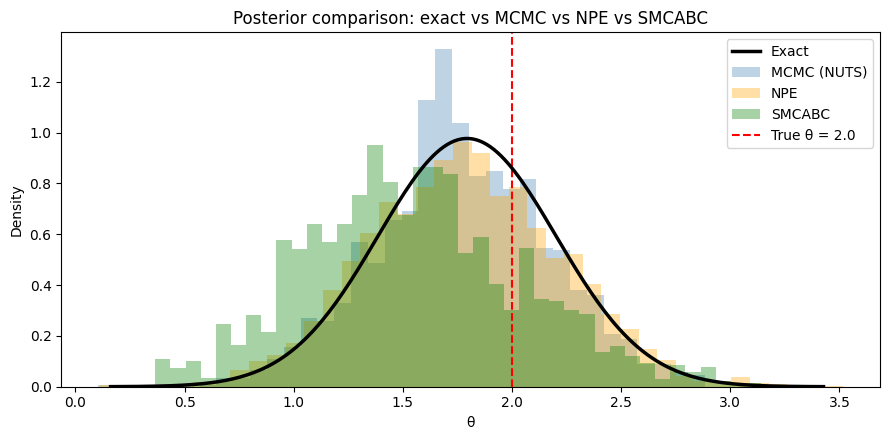

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(x_grid, exact_pdf, 'k-', lw=2.5, label='Exact', zorder=5)
ax.hist(draws_mcmc, bins=40, density=True, alpha=0.35, color='steelblue', label='MCMC (NUTS)')
ax.hist(np.array(posterior_npe.draws()).ravel(), bins=40, density=True, alpha=0.35, color='orange', label='NPE')
ax.hist(np.array(posterior_abc.draws()).ravel(), bins=40, density=True, alpha=0.35, color='green', label='SMCABC')
ax.axvline(theta_true, color='red', ls='--', lw=1.5, label=f'True θ = {theta_true}')

ax.set(xlabel='θ', ylabel='Density',
       title='Posterior comparison: exact vs MCMC vs NPE vs SMCABC')
ax.legend(); plt.tight_layout(); plt.show()

In [12]:
results = {
    'Exact':  (exact_mean, exact_std),
    'MCMC':   (mean(posterior_mcmc).item(), jnp.sqrt(variance(posterior_mcmc)).item()),
    'NPE':    (mean(posterior_npe).item(), jnp.sqrt(variance(posterior_npe)).item()),
    'SMCABC': (mean(posterior_abc).item(), jnp.sqrt(variance(posterior_abc)).item()),
}

print(f'{"Method":<10} {"Mean":>8} {"Std":>8}')
print('-' * 28)
for name, (m, s) in results.items():
    print(f'{name:<10} {m:>8.3f} {s:>8.3f}')

Method         Mean      Std
----------------------------
Exact         1.794    0.408
MCMC          1.773    0.399
NPE           1.780    0.444
SMCABC        1.553    0.499


## 8. Amortization: reusing trained models

The defining advantage of amortized methods like NPE is that the trained model can be reused for different observations without re-training. This is critical in settings like:

- **Repeated experiments** — analyzing many datasets from the same instrument
- **Online inference** — updating beliefs as new data arrives
- **Sensitivity analysis** — exploring how the posterior changes with different observations

Here we condition the same trained NPE model on three different observed datasets. Each `condition_on` call takes milliseconds — the expensive training was done once.

In [13]:
keys = jax.random.split(jax.random.PRNGKey(0), 3)
observations = [
    theta_true + noise_scale * jax.random.normal(k, shape=(n_obs,))
    for k in keys
]

posteriors_npe = [condition_on(trained_model, y) for y in observations]

for i, (y, post) in enumerate(zip(observations, posteriors_npe)):
    print(f'Observation {i + 1}: mean(y) = {jnp.mean(y).item():.3f},  '
          f'posterior mean = {mean(post).item():.3f}')

Observation 1: mean(y) = 1.461,  posterior mean = 1.234
Observation 2: mean(y) = 0.922,  posterior mean = 0.786
Observation 3: mean(y) = 2.370,  posterior mean = 1.945


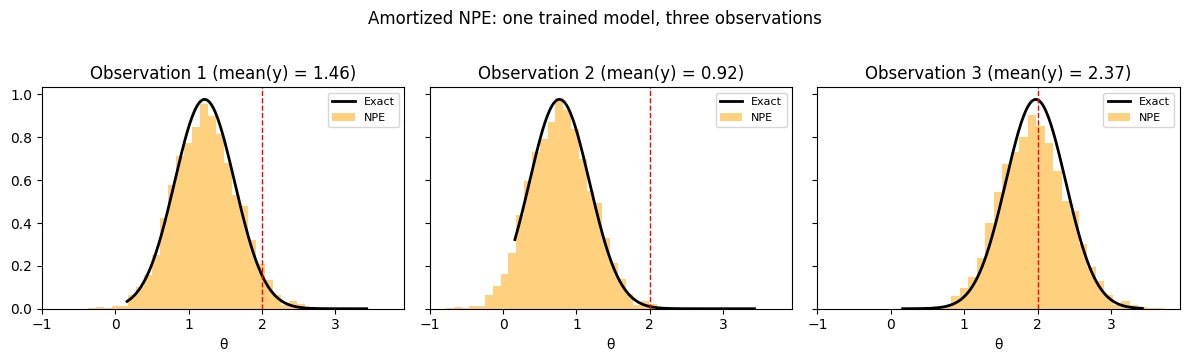

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, sharey=True)

for ax, y, post, i in zip(axes, observations, posteriors_npe, range(3)):
    exact_mean_i = float(
        (n_obs * jnp.mean(y) / noise_scale**2)
        / (1 / prior_var + n_obs / noise_scale**2)
    )
    ax.plot(x_grid, jax.scipy.stats.norm.pdf(x_grid, exact_mean_i, exact_std),
            'k-', lw=2, label='Exact')
    ax.hist(np.array(post.draws()).ravel(), bins=30, density=True,
            alpha=0.5, color='orange', label='NPE')
    ax.axvline(theta_true, color='red', ls='--', lw=1)
    ax.set(xlabel='θ', title=f'Observation {i + 1} (mean(y) = {jnp.mean(y).item():.2f})')
    ax.legend(fontsize=8)

plt.suptitle('Amortized NPE: one trained model, three observations', y=1.02)
plt.tight_layout(); plt.show()

## 9. How SBI fits the ProbPipe paradigm

The Getting Started tutorial established ProbPipe's core design: **protocol-based dispatch through a unified `condition_on` interface**. SBI extends this naturally:

1. **Same entry point.** Whether you use MCMC or SBI, the call is `condition_on(model, data)`. The model type and available protocols determine the inference algorithm.

2. **Same output type.** MCMC, NPE, and SMCABC all return `ApproximateDistribution` — an empirical distribution with chain structure, an `.algorithm` tag, and optional ArviZ `InferenceData` for diagnostics. Downstream operations (`mean`, `variance`, `sample`, `predictive_check`, uncertainty propagation via `WorkflowFunction`) work identically regardless of how the posterior was computed.

3. **Protocol-driven dispatch.** `SimpleModel` implements `SupportsLogProb`, so MCMC methods are feasible. `SimpleGenerativeModel` does not, so the registry skips MCMC and selects SBI methods instead. `TrainedSBIModel` implements `SupportsConditioning`, so `condition_on` calls the trained network directly — bypassing the registry entirely.

4. **Provenance tracking.** Every `ApproximateDistribution` records its lineage — which algorithm, which parents, which metadata — regardless of whether it came from NUTS or NPE. This makes multi-method workflows auditable.

## 10. When to use which method

| Method | When to use | Strengths | Limitations |
|--------|-------------|-----------|-------------|
| **MCMC** (NUTS, HMC) | Likelihood available and differentiable | Gold standard; well-understood diagnostics | Requires tractable, differentiable likelihood |
| **MCMC** (RWMH) | Likelihood available but not differentiable | Gradient-free | Slower convergence in high dimensions |
| **NPE** (amortized) | Many observations under the same model | Train once, condition instantly | Upfront training cost; approximation quality depends on network capacity and training data |
| **SMCABC** (non-amortized) | One-off inference with a simulator | No training step; directly targets each observation | Slower per observation; scales poorly to high-dimensional data |

ProbPipe's registry makes switching between these methods a one-line change — swap the model type or pass `method=` to `condition_on`.

### References

- Cranmer, K., Brehmer, J. & Louppe, G. (2020). [The frontier of simulation-based inference](https://doi.org/10.1073/pnas.1912789117). *Proceedings of the National Academy of Sciences*, 117(48), 30055–30062.
- Lueckmann, J.-M., Boelts, J., Greenberg, D., Gonçalves, P. & Macke, J. (2021). [Benchmarking simulation-based inference](https://proceedings.mlr.press/v130/lueckmann21a.html). *AISTATS 2021*.
- Papamakarios, G. & Murray, I. (2016). [Fast ε-free inference of simulation models with Bayesian conditional density estimation](https://papers.nips.cc/paper/6084-fast-free-inference-of-simulation-models-with-bayesian-conditional-density-estimation). *NeurIPS 2016*.
- Sisson, S.A., Fan, Y. & Beaumont, M.A. (2007). [Sequential Monte Carlo without likelihoods](https://doi.org/10.1073/pnas.0607208104). *Proceedings of the National Academy of Sciences*, 104(6), 1760–1765.
- Toni, T., Welch, D., Strelkowa, N., Ipsen, A. & Stumpf, M.P.H. (2009). [Approximate Bayesian computation scheme for parameter inference and model selection in dynamical systems](https://doi.org/10.1098/rsif.2008.0172). *Journal of the Royal Society Interface*, 6(31), 187–202.

### Next steps

- [API Reference — Inference](../api/inference.md)
- [Reference Notebooks](../reference_notebooks.md)